# Basket Options: Multi-Asset Pricing

**Notebook 6** of a series implementing **Stamatopoulos et al., *"Option Pricing using Quantum Computers"*** [arXiv:1905.02666](https://arxiv.org/abs/1905.02666), Section 4.2.1.

A companion write-up is available on [Medium Blog](https://medium.com/@arpitha.rajeev37/implementing-option-pricing-using-quantum-computers-in-qiskit-part-4-the-quantum-weighted-sum-bd78812e44c0).

Vanilla and portfolio options (Notebooks 3-4) depend on a single asset's price at a single point in time. A **basket option** depends on a *weighted combination* of several assets' prices -- e.g. 60% Apple, 40% Google. This notebook puts Notebook 5's weighted-sum operator to work: load two independent price distributions, combine them with the verified adder, then reuse the same comparator-plus-payoff-rotation pipeline from Notebooks 3-4 on the combined register.

**What this notebook does:**
1. Define the two-asset contract and compute the classical ground truth (assuming independence between the two assets).
2. Load both assets' distributions onto one 4-qubit register.
3. Compose the weighted-sum operator from Notebook 5 to produce a combined `sum` register.
4. Build a comparator and payoff rotation on that combined register -- identical in kind to Notebooks 3-4, just pointed at a different register.
5. Verify against ground truth, run Amplitude Estimation, and execute on real hardware.

## Setup

In [21]:
import numpy as np
import sympy as sp
from qiskit import QuantumCircuit
from qiskit.circuit.library import StatePreparation, WeightedAdder, IntegerComparator
from qiskit.quantum_info import Statevector
from qiskit_algorithms import EstimationProblem, IterativeAmplitudeEstimation
from qiskit.primitives import StatevectorSampler
from qiskit.circuit.library import RYGate

## The contract

A basket call option: `Basket = 0.6*Apple_price + 0.4*Google_price`, payoff `max(0, Basket - K)`. Assuming (for this example) that Apple and Google move independently, the joint probability of any (Apple price, Google price) combination is just the product of their individual probabilities.

In [22]:
apple_prices = [120, 140, 160, 180]
apple_probs = [0.20, 0.35, 0.30, 0.15]
google_prices = [90, 100, 110, 120]
google_probs = [0.25, 0.30, 0.25, 0.20]

w_apple, w_google = 0.6, 0.4
K = 130

expected_payoff_truth = 0.0
for ap, apr in zip(apple_prices, apple_probs):
    for gp, gpr in zip(google_prices, google_probs):
        basket = w_apple*ap + w_google*gp
        expected_payoff_truth += apr * gpr * max(0, basket - K)

print('Ground truth expected payoff:', expected_payoff_truth)

Ground truth expected payoff: 5.36


## Component 1: distribution loading for both assets

`StatePreparation` takes the full amplitude list directly -- 16 amplitudes for the joint (Apple, Google) state, each the square root of the corresponding joint probability. Qubits 0,1 encode Apple's index; qubits 2,3 encode Google's index.

In [23]:
amplitudes = np.zeros(16)
for gi, (gp, gpr) in enumerate(zip(google_prices, google_probs)):
    for ai, (ap, apr) in enumerate(zip(apple_prices, apple_probs)):
        index = (gi << 2) | ai
        amplitudes[index] = np.sqrt(apr * gpr)

state_prep = StatePreparation(amplitudes)

### Verifying the joint distribution

In [24]:
sv_check = Statevector(state_prep)
result_check = sv_check.probabilities_dict()

# spot check a few branches
for label in ['0000', '0101', '1111']:
    q3, q2, q1, q0 = int(label[0]), int(label[1]), int(label[2]), int(label[3])
    google_idx = q3*2 + q2
    apple_idx = q1*2 + q0
    expected = apple_probs[apple_idx] * google_probs[google_idx]
    got = result_check.get(label, 0)
    print(f'{label}: Apple=${apple_prices[apple_idx]}, Google=${google_prices[google_idx]}, '
          f'got P={got:.4f}, expected P={expected:.4f}, match={np.isclose(got, expected)}')

0000: Apple=$120, Google=$90, got P=0.0500, expected P=0.0500, match=True
0101: Apple=$140, Google=$100, got P=0.1050, expected P=0.1050, match=True
1111: Apple=$180, Google=$120, got P=0.0300, expected P=0.0300, match=True


## Component 2a: the weighted sum (Notebook 5's operator, applied here)

Deriving the per-qubit weights and baseline offset, exactly as worked out in Notebook 5.

In [25]:
i, j = sp.symbols('i j')
w_apple_r, w_google_r = sp.Rational(6, 10), sp.Rational(4, 10)
apple_intercept, apple_slope = 120, 20
google_intercept, google_slope = 90, 10

S_basket = w_apple_r*(apple_intercept + apple_slope*i) + w_google_r*(google_intercept + google_slope*j)
S_basket_expanded = sp.expand(S_basket)

baseline = float(S_basket_expanded.subs({i: 0, j: 0}))
i_coeff = S_basket_expanded.coeff(i)
j_coeff = S_basket_expanded.coeff(j)

weights = [int(i_coeff*1), int(i_coeff*2), int(j_coeff*1), int(j_coeff*2)]
print('baseline:', baseline, '| weights:', weights)

adder = WeightedAdder(num_state_qubits=4, weights=weights)
print(adder.qregs)

baseline: 108.0 | weights: [12, 24, 4, 8]
[QuantumRegister(4, 'state'), QuantumRegister(6, 'sum'), QuantumRegister(5, 'carry'), QuantumRegister(1, 'control')]


## Component 2b: comparator and payoff rotation on the combined register

The strike `K` has to be shifted into the same units as the `sum` register -- since the register only holds the *variable* part of the basket value, the baseline offset has to be subtracted from `K` before comparing.

In [26]:
K_shifted = K - baseline
sum_size = adder.qregs[1].size
print('K_shifted:', K_shifted, '| sum register width:', sum_size)

comparator = IntegerComparator(sum_size, K_shifted, geq=True)
print(comparator.qregs)

K_shifted: 22.0 | sum register width: 6
[QuantumRegister(6, 'state'), QuantumRegister(1, 'compare'), QuantumRegister(5, 'a10')]


We calculate the angle using Eq.20-Eq.21

In [27]:
# Maximum achievable payoff (48 - 22 = 26)
max_achievable_sum = sum(weights)
payoff_range = max_achievable_sum - K_shifted  # 26

c = 0.25
g_slope = 2 * c / payoff_range

rot_base = 2 * (np.pi / 4 - c)
rot_strike_offset = -2 * g_slope * K_shifted
rot_angles = [2 * g_slope * (2**k) for k in range(sum_size)]

print(f'K_shifted: {K_shifted} | sum_size: {sum_size}')
print(f'rot_base: {rot_base:.4f} | rot_strike_offset: {rot_strike_offset:.4f}')
print('rot_angles:', [round(a, 4) for a in rot_angles])

K_shifted: 22.0 | sum_size: 6
rot_base: 1.0708 | rot_strike_offset: -0.8462
rot_angles: [np.float64(0.0385), np.float64(0.0769), np.float64(0.1538), np.float64(0.3077), np.float64(0.6154), np.float64(1.2308)]


## Assembling the full A operator

State preparation → weighted sum → comparator → payoff rotation, using the same qubit-composition bookkeeping pattern from Notebook 5 -- each library gate's `qregs` sizes determine where the next piece attaches.

In [28]:
# 1. Setup registers and circuit
total_qubits = 4 + (adder.num_qubits - 4) + (comparator.num_qubits - sum_size) + 1
qc_A = QuantumCircuit(total_qubits)

# 2. State Preparation & Adder
qc_A.compose(state_prep, qubits=range(4), inplace=True)
qc_A.compose(adder, qubits=range(adder.num_qubits), inplace=True)

# 3. Comparator
sum_qubits = list(range(4, 4 + sum_size))
comparator_extra = list(range(adder.num_qubits, adder.num_qubits + (comparator.num_qubits - sum_size)))
print(comparator_extra)
qc_A.compose(comparator, qubits=sum_qubits + comparator_extra, inplace=True)

comparator_qubit = comparator_extra[0]
payoff_qubit = total_qubits - 1

# 4. Apply rotations
# (a) Base angle for all paths (payoff = 0 baseline)
qc_A.ry(rot_base, payoff_qubit)

# (b) Strike offset when comparator flag == 1 (x >= K_shifted)
qc_A.append(RYGate(rot_strike_offset).control(1), [comparator_qubit, payoff_qubit])

# (c) Linear sum rotations when comparator flag == 1 and sum bit k == 1
for k, angle in enumerate(rot_angles):
    qc_A.append(RYGate(angle).control(2), [comparator_qubit, sum_qubits[k], payoff_qubit])

print('Total qubits:', qc_A.num_qubits, '| payoff qubit index:', payoff_qubit)

[16, 17, 18, 19, 20, 21]
Total qubits: 23 | payoff qubit index: 22


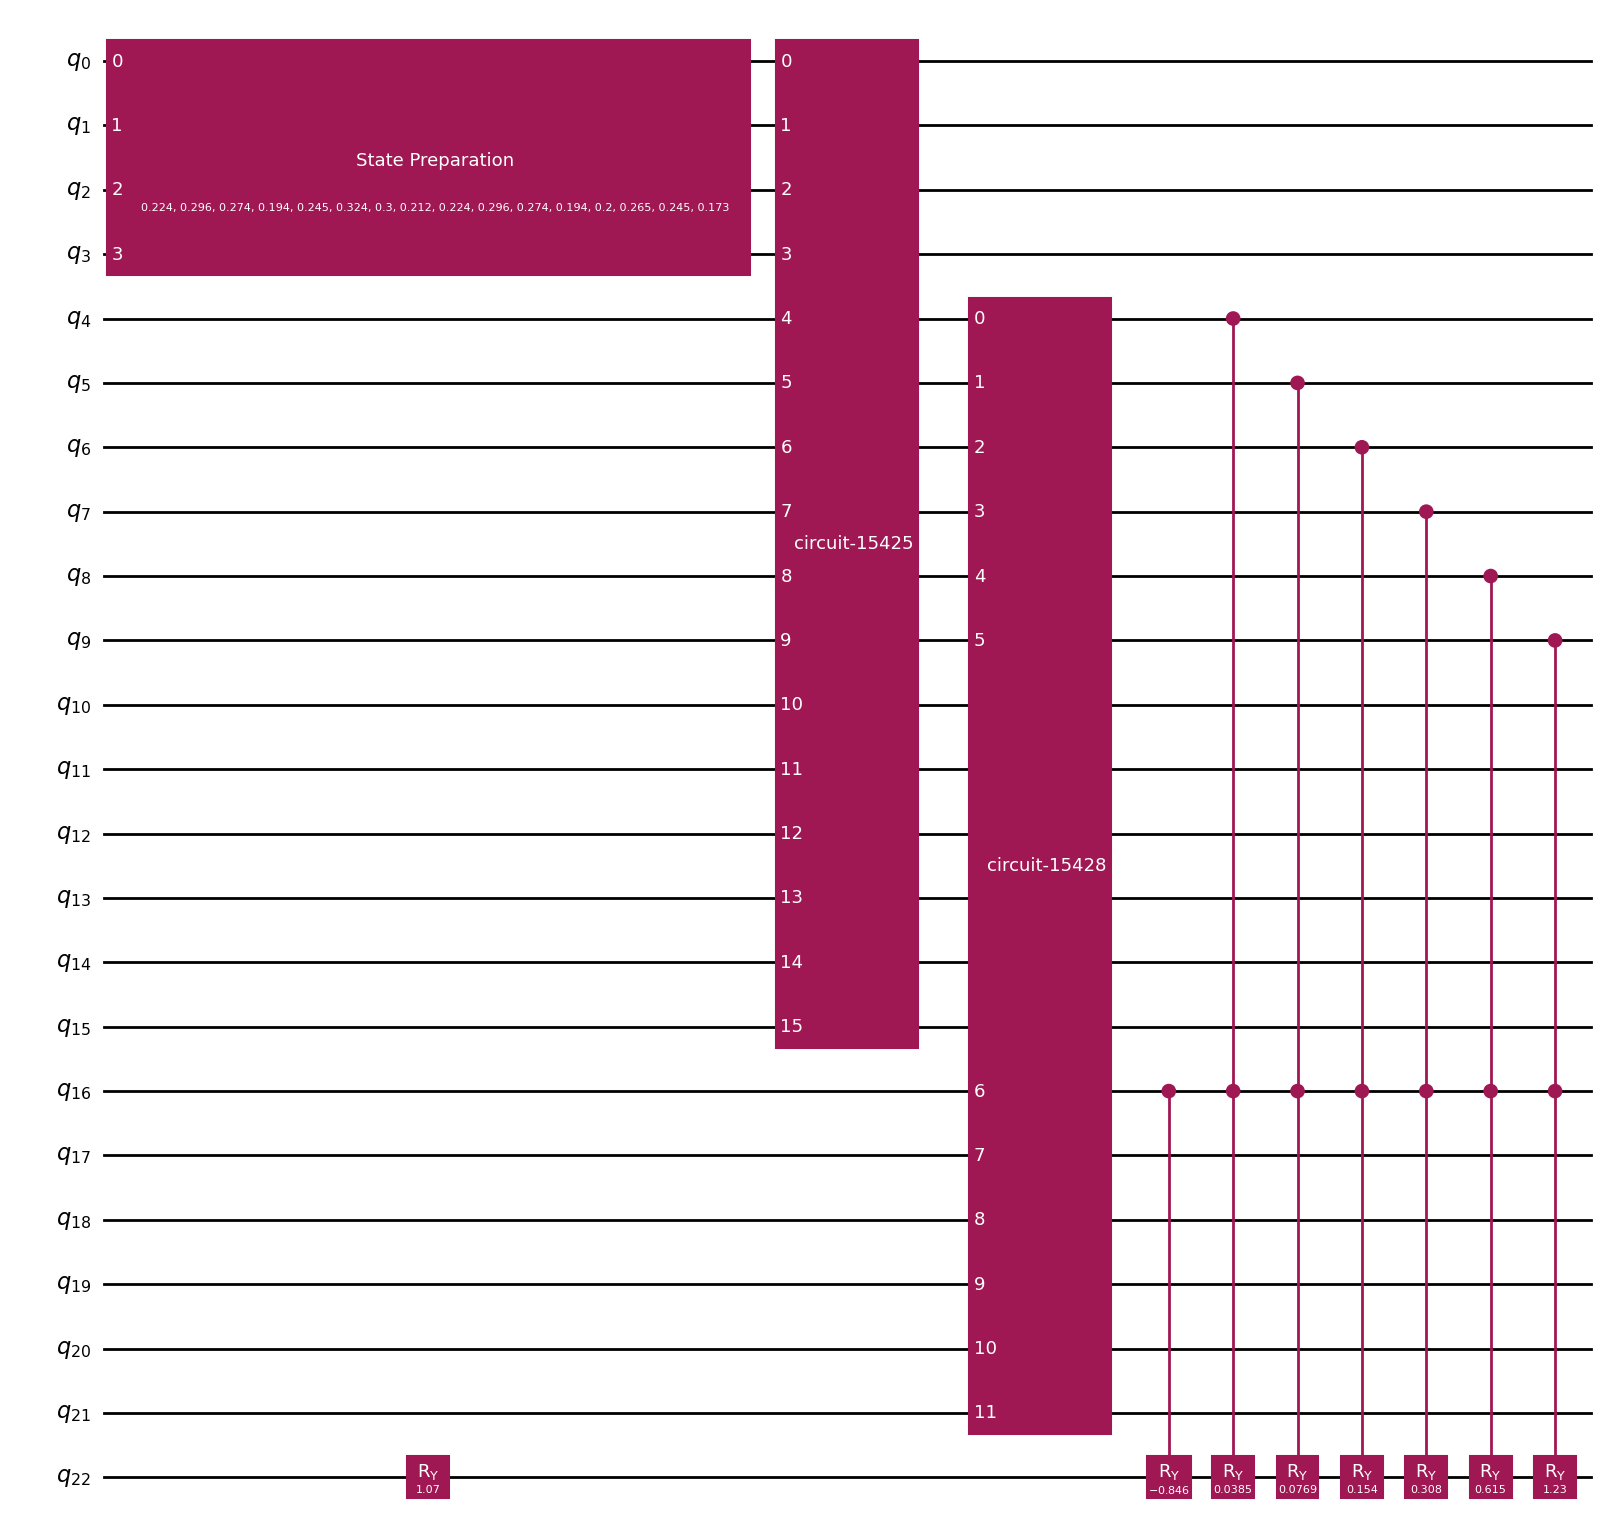

In [29]:
qc_A.draw("mpl")

### Verifying the full `A` operator against ground truth

In [10]:
sv_A = Statevector(qc_A)
result_A = sv_A.probabilities_dict()
f_max = sum(weights) - K_shifted
raw_p1 = sum(v for k, v in result_A.items() if k[0] == '1')

def post_process(a):
    return (a - 0.5 + c) * (f_max - 0) / (2*c) + 0

estimated_payoff = post_process(raw_p1)
print('P(payoff=1):', raw_p1)
print('Reconstructed expected payoff:', estimated_payoff)
print('Ground truth:                ', expected_payoff_truth)
print('Match (within approximation tolerance):', abs(estimated_payoff - expected_payoff_truth) < 1.0)

P(payoff=1): 0.35861257754289655
Reconstructed expected payoff: 5.6478540322306205
Ground truth:                 5.36
Match (within approximation tolerance): True


**Note:** this uses the linear-approximation rotation formula (Eq. 20-21), the same one Notebook 3 discussed but did not use directly for its own toy example. Some residual approximation error relative to ground truth is expected here -- controlled by `c` -- rather than the exact match Notebooks 3-4's `arcsin`-per-branch approach gave.

## Amplitude Estimation

In [11]:
problem = EstimationProblem(
    state_preparation=qc_A,
    objective_qubits=[payoff_qubit],
    post_processing=post_process,
)

sampler = StatevectorSampler()
iae = IterativeAmplitudeEstimation(epsilon_target=0.1, alpha=0.05, sampler=sampler)
result_iae = iae.estimate(problem)

print('Ground truth:      ', expected_payoff_truth)
print('IAE estimate:      ', result_iae.estimation_processed)

Ground truth:       5.36
IAE estimate:       5.110797331647729


## Map → Optimize → Execute → Post-process on real hardware

Reusing the custom transpiling sampler wrapper from Notebook 3, which dynamically transpiles the internally-generated `AQ^k` circuits and patches the `shots` metadata key needed by this `qiskit-algorithms` version.

In [30]:
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as RuntimeSampler
from qiskit.transpiler import generate_preset_pass_manager

service = QiskitRuntimeService()
backend = service.least_busy(operational=True, simulator=False)
print('Using backend:', backend.name)

pm_hw = generate_preset_pass_manager(optimization_level=3, backend=backend)

Using backend: ibm_marrakesh


In [31]:
class HardwareTranspiledSampler:
    def __init__(self, sampler, pass_manager):
        self._sampler = sampler
        self._pm = pass_manager

    def run(self, pubs, **kwargs):
        transpiled_pubs = []
        for pub in pubs:
            if isinstance(pub, tuple):
                circuit = self._pm.run(pub[0])
                transpiled_pubs.append((circuit, *pub[1:]))
            else:
                circuit = self._pm.run(pub)
                transpiled_pubs.append(circuit)
        job = self._sampler.run(transpiled_pubs, **kwargs)
        original_result = job.result
        def patched_result(*args, **kwargs_res):
            res = original_result(*args, **kwargs_res)
            for pub_res in res:
                if 'shots' not in pub_res.metadata:
                    reg_name = next(iter(pub_res.data.keys()))
                    bit_array = getattr(pub_res.data, reg_name)
                    pub_res.metadata['shots'] = bit_array.num_shots
            return res
        job.result = patched_result
        return job

In [ ]:
base_sampler = RuntimeSampler(mode=backend)
hardware_sampler = HardwareTranspiledSampler(base_sampler, pm_hw)

In [14]:
problem_hw = EstimationProblem(
    state_preparation=qc_A,  
    objective_qubits=[payoff_qubit],
    post_processing=post_process,
)

iae_hw = IterativeAmplitudeEstimation(epsilon_target=0.1, alpha=0.05, sampler=hardware_sampler)
result_iae_hw = iae_hw.estimate(problem_hw)

print('Ground truth:                  ', expected_payoff_truth)
print('IAE estimate (real hardware): ', result_iae_hw.estimation_processed)

Ground truth:                   5.36
IAE estimate (real hardware):  10.121111651546705


## Results Summary

- Two independent asset distributions loaded onto one joint 4-qubit register, verified against the product of their individual probabilities.
- Notebook 5's weighted-sum operator, composed directly into this circuit, correctly combines both assets into one `sum` register -- reusing a fully independently-verified building block rather than re-deriving it.
- The comparator and payoff rotation stages are structurally identical to Notebooks 3-4, applied to the combined register instead of a single price register -- no new circuit *types* were needed, only a new register to point them at.
- Amplitude Estimation, and the same real-hardware execution pattern (including the custom transpiling sampler wrapper from Notebook 3), carry over unchanged.

## What's Next

**Notebook 7** covers **Asian options** -- structurally near-identical to this notebook, with the key difference being *equal* weights (an average across time checkpoints of the *same* asset) rather than custom weights across *different* assets. **Notebook 8** introduces the one remaining new circuit idea: a logical **OR** across multiple barrier-crossing checks, for **barrier options**.